In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# ============================================================
# Basic geometry
# ============================================================

def cross_matrix(v):
    """
    Matrix [v]_x such that

        [v]_x @ w = v x w
    """
    x, y, z = v

    return np.array([
        [0.0, -z,   y],
        [z,    0.0, -x],
        [-y,   x,   0.0]
    ])


# ============================================================
# Rigid body
# ============================================================

class RigidBody:

    def __init__(self, position, mass=1.0, inertia=None, orientation=None):

        self.position = np.asarray(position, dtype=float)

        self.mass = float(mass)

        if inertia is None:
            inertia = np.eye(3)

        self.inertia = np.asarray(inertia, dtype=float)

        if orientation is None:
            orientation = np.eye(3)

        self.orientation = np.asarray(orientation, dtype=float)

    def mass_matrix(self):
        """
        6x6 mass matrix in coordinates

            q = (u_x, u_y, u_z, theta_x, theta_y, theta_z)
        """

        M = np.zeros((6, 6))

        M[:3, :3] = self.mass * np.eye(3)

        # Inertia tensor expressed in the global equilibrium frame
        I_global = (
            self.orientation
            @ self.inertia
            @ self.orientation.T
        )

        M[3:, 3:] = I_global

        return M


# ============================================================
# Pair interaction
# ============================================================

class Bond:

    def __init__(self,
                 alpha,
                 beta,
                 lattice_shift,
                 K):
        """
        Parameters
        ----------
        alpha, beta : int
            Indices of the bodies in the unit cell.

        lattice_shift : array_like, shape (3,)
            Cartesian lattice translation connecting

                alpha in cell R

            to

                beta in cell R + lattice_shift.

        K : array_like, shape (6, 6)
            Symmetric stiffness matrix acting on

                z = (delta_u, delta_theta)

        where

            delta_u =
                u_beta - u_alpha
                - theta_alpha x d

            delta_theta =
                theta_beta - theta_alpha
        """

        self.alpha = alpha
        self.beta = beta

        self.shift = np.asarray(lattice_shift, dtype=float)

        self.K = np.asarray(K, dtype=float)

        if self.K.shape != (6, 6):
            raise ValueError("K must be 6x6")

        if not np.allclose(self.K, self.K.T):
            raise ValueError("K must be symmetric")


# ============================================================
# Crystal
# ============================================================

class RigidBodyCrystal:

    def __init__(self, lattice_vectors, bodies, bonds):

        self.lattice_vectors = np.asarray(
            lattice_vectors,
            dtype=float
        )

        self.bodies = list(bodies)
        self.bonds = list(bonds)

        self.n_bodies = len(bodies)

        self.ndof = 6 * self.n_bodies


    # --------------------------------------------------------
    # Bond Hessian
    # --------------------------------------------------------

    def bond_hessian(self, bond):

        alpha = bond.alpha
        beta = bond.beta

        rA = self.bodies[alpha].position

        rB = (
            self.bodies[beta].position
            + bond.shift
        )

        d = rB - rA

        X = cross_matrix(d)

        I3 = np.eye(3)
        Z3 = np.zeros((3, 3))

        # z = L q
        #
        # q = (u_A, theta_A, u_B, theta_B)

        L = np.block([
            [-I3, X,   I3, Z3],
            [ Z3, -I3, Z3, I3]
        ])

        H = L.T @ bond.K @ L

        return H


    # --------------------------------------------------------
    # Real-space force constants
    # --------------------------------------------------------

    def force_constants(self):

        """
        Returns a dictionary

            Phi[(alpha, beta, R)]

        containing the 6x6 block coupling

            alpha in cell 0

        to

            beta in cell R.
        """

        Phi = {}

        def add_block(alpha, beta, R, block):

            key = (
                alpha,
                beta,
                tuple(np.asarray(R, dtype=float))
            )

            if key not in Phi:
                Phi[key] = np.zeros((6, 6))

            Phi[key] += block


        for bond in self.bonds:

            H = self.bond_hessian(bond)

            alpha = bond.alpha
            beta = bond.beta

            R = bond.shift

            # Split 12x12 Hessian into 6x6 blocks

            H_AA = H[:6, :6]
            H_AB = H[:6, 6:]

            H_BA = H[6:, :6]
            H_BB = H[6:, 6:]

            # alpha(0) - beta(R)

            add_block(alpha, alpha, np.zeros(3), H_AA)

            add_block(alpha, beta, R, H_AB)

            add_block(beta, alpha, -R, H_BA)

            add_block(beta, beta, np.zeros(3), H_BB)

        return Phi


    # --------------------------------------------------------
    # k-space stiffness matrix
    # --------------------------------------------------------

    def stiffness_matrix(self, k):

        """
        Construct the 6N x 6N Bloch stiffness matrix.
        """

        k = np.asarray(k, dtype=float)

        Phi = self.force_constants()

        Kk = np.zeros(
            (self.ndof, self.ndof),
            dtype=complex
        )

        for (alpha, beta, R_tuple), block in Phi.items():

            R = np.array(R_tuple)

            phase = np.exp(1j * np.dot(k, R))

            ia = slice(6 * alpha, 6 * (alpha + 1))
            ib = slice(6 * beta, 6 * (beta + 1))

            Kk[ia, ib] += block * phase

        return Kk


    # --------------------------------------------------------
    # Mass matrix
    # --------------------------------------------------------

    def mass_matrix(self):

        M = np.zeros(
            (self.ndof, self.ndof)
        )

        for alpha, body in enumerate(self.bodies):

            sl = slice(
                6 * alpha,
                6 * (alpha + 1)
            )

            M[sl, sl] = body.mass_matrix()

        return M


    # --------------------------------------------------------
    # Dynamical matrix
    # --------------------------------------------------------

    def dynamical_matrix(self, k):

        Kk = self.stiffness_matrix(k)

        M = self.mass_matrix()

        # M^{-1/2}

        eigvals, eigvecs = np.linalg.eigh(M)

        M_inv_sqrt = (
            eigvecs
            @ np.diag(1.0 / np.sqrt(eigvals))
            @ eigvecs.T
        )

        D = (
            M_inv_sqrt
            @ Kk
            @ M_inv_sqrt
        )

        # Remove tiny numerical non-Hermiticity

        D = 0.5 * (D + D.conj().T)

        return D


    # --------------------------------------------------------
    # Eigenmodes
    # --------------------------------------------------------

    def modes(self, k):

        D = self.dynamical_matrix(k)

        eigvals, eigvecs = np.linalg.eigh(D)

        # Small negative numerical eigenvalues -> zero
        eigvals[np.abs(eigvals) < 1e-12] = 0.0

        frequencies = np.sqrt(
            np.maximum(eigvals, 0.0)
        )

        return frequencies, eigvecs


# ============================================================
# Reciprocal lattice
# ============================================================

def reciprocal_lattice(lattice_vectors):

    """
    Rows of lattice_vectors are real-space primitive vectors.
    """

    A = np.asarray(lattice_vectors)

    return (
        2.0 * np.pi
        * np.linalg.inv(A).T
    )


# ============================================================
# k-path interpolation
# ============================================================

def interpolate_kpath(points, n_per_segment=50):

    ks = []
    distances = [0.0]

    total_distance = 0.0

    for p0, p1 in zip(points[:-1], points[1:]):

        segment = np.linspace(
            p0,
            p1,
            n_per_segment,
            endpoint=False
        )

        for k in segment:

            if len(ks) > 0:

                total_distance += np.linalg.norm(
                    k - ks[-1]
                )

                distances.append(total_distance)

            ks.append(k)

    ks.append(points[-1])

    total_distance += np.linalg.norm(
        points[-1] - ks[-2]
    )

    distances.append(total_distance)

    return np.array(ks), np.array(distances)


# ============================================================
# Band structure
# ============================================================

def compute_band_structure(crystal, kpoints):

    frequencies = []

    eigenvectors = []

    for k in kpoints:

        w, v = crystal.modes(k)

        frequencies.append(w)
        eigenvectors.append(v)

    return (
        np.array(frequencies),
        np.array(eigenvectors)
    )


def plot_band_structure(
        distances,
        frequencies,
        special_distances=None,
        special_labels=None):

    plt.figure(figsize=(7, 5))

    for band in range(frequencies.shape[1]):

        plt.plot(
            distances,
            frequencies[:, band]
        )

    if special_distances is not None:

        for x in special_distances:

            plt.axvline(
                x,
                linewidth=0.8
            )

        if special_labels is not None:

            plt.xticks(
                special_distances,
                special_labels
            )

    plt.ylabel(r"$\omega$")
    plt.xlabel("wavevector")

    plt.tight_layout()

    plt.show()

In [2]:
a = 1.0

lattice_vectors = np.array([
    [a, 0.0, 0.0],
    [0.0, a, 0.0],
    [0.0, 0.0, a]
])


body = RigidBody(
    position=[0.0, 0.0, 0.0],
    mass=1.0,
    inertia=np.diag([0.4, 0.7, 1.0])
)


# Translational stiffness
A = np.array([
    [2.0, 0.2, 0.0],
    [0.2, 1.5, 0.1],
    [0.0, 0.1, 1.0]
])

# Translation-rotation coupling
B = 4*np.array([
    [0.0, 0.3, 0.1],
    [-0.2, 0.0, 0.2],
    [0.1, -0.1, 0.0]
])

# Rotational stiffness
D = np.array([
    [0.8, 0.1, 0.0],
    [0.1, 1.2, 0.2],
    [0.0, 0.2, 0.6]
])


K = np.block([
    [A, B],
    [B.T, D]
])


bonds = [

    Bond(
        alpha=0,
        beta=0,
        lattice_shift=[a, 0.0, 0.0],
        K=K
    ),

    Bond(
        alpha=0,
        beta=0,
        lattice_shift=[0.0, a, 0.0],
        K=K
    ),

    Bond(
        alpha=0,
        beta=0,
        lattice_shift=[0.0, 0.0, a],
        K=K
    )
]


crystal = RigidBodyCrystal(
    lattice_vectors=lattice_vectors,
    bodies=[body],
    bonds=bonds
)

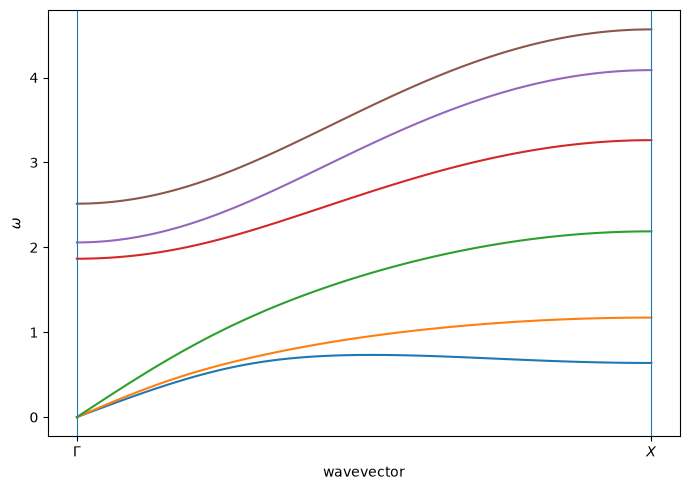

In [3]:
Brec = reciprocal_lattice(
    lattice_vectors
)

Gamma = np.array([0.0, 0.0, 0.0])

X = 0.5 * Brec[0]


kpoints, distances = interpolate_kpath(
    [Gamma, X],
    n_per_segment=100
)


frequencies, eigenvectors = (
    compute_band_structure(
        crystal,
        kpoints
    )
)


plot_band_structure(
    distances,
    frequencies,
    special_distances=[
        distances[0],
        distances[-1]
    ],
    special_labels=[
        r"$\Gamma$",
        r"$X$"
    ]
)

In [4]:
def rotation_matrix_small(theta):
    """
    Rodrigues rotation matrix for visualization.
    """

    angle = np.linalg.norm(theta)

    if angle < 1e-12:
        return np.eye(3)

    axis = theta / angle

    X = cross_matrix(axis)

    return (
        np.eye(3)
        + np.sin(angle) * X
        + (1.0 - np.cos(angle)) * (X @ X)
    )

In [5]:
def animate_mode(
        crystal,
        k,
        eigenvector,
        frequency,
        cells,
        amplitude=0.1,
        n_frames=100):

    """
    Animate a Bloch eigenmode.

    Parameters
    ----------
    cells : list of integer triples

        Example:

            cells = [
                (0,0,0),
                (1,0,0),
                (2,0,0)
            ]
    """

    fig = plt.figure(figsize=(7, 7))

    ax = fig.add_subplot(
        111,
        projection="3d"
    )


    # Build equilibrium body positions

    equilibrium = []

    for cell in cells:

        cell = np.asarray(cell)

        Rcell = (
            cell[0] * crystal.lattice_vectors[0]
            + cell[1] * crystal.lattice_vectors[1]
            + cell[2] * crystal.lattice_vectors[2]
        )

        for alpha, body in enumerate(crystal.bodies):

            equilibrium.append(
                (Rcell, alpha,
                 Rcell + body.position)
            )


    all_positions = np.array([
        x[2]
        for x in equilibrium
    ])

    xmin = all_positions[:, 0].min() - 1
    xmax = all_positions[:, 0].max() + 1

    ymin = all_positions[:, 1].min() - 1
    ymax = all_positions[:, 1].max() + 1

    zmin = all_positions[:, 2].min() - 1
    zmax = all_positions[:, 2].max() + 1


    def update(frame):

        ax.cla()

        phase_time = (
            -2.0
            * np.pi
            * frame
            / n_frames
        )


        for Rcell, alpha, r0 in equilibrium:

            sl = slice(
                6 * alpha,
                6 * (alpha + 1)
            )

            v_alpha = eigenvector[sl]

            phase = np.exp(
                1j * (
                    np.dot(k, Rcell)
                    + phase_time
                )
            )

            q = np.real(
                amplitude
                * v_alpha
                * phase
            )

            u = q[:3]

            theta = q[3:]

            position = r0 + u


            body = crystal.bodies[alpha]

            # Equilibrium orientation

            R_eq = body.orientation

            # Oscillating orientation

            R_rot = (
                rotation_matrix_small(theta)
                @ R_eq
            )


            ax.scatter(
                position[0],
                position[1],
                position[2],
                s=60,
                c='b'
            )


            # Draw body axes

            axis_length = 0.3

            for j in range(3):

                direction = (
                    R_rot[:, j]
                    * axis_length
                )

                ax.plot(
                    [
                        position[0],
                        position[0] + direction[0]
                    ],
                    [
                        position[1],
                        position[1] + direction[1]
                    ],
                    [
                        position[2],
                        position[2] + direction[2]
                    ],
                     c='k')


        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_zlim(zmin, zmax)

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")

        ax.set_title(
            f"ω = {frequency:.4f}"
        )


    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=50
    );

    return animation

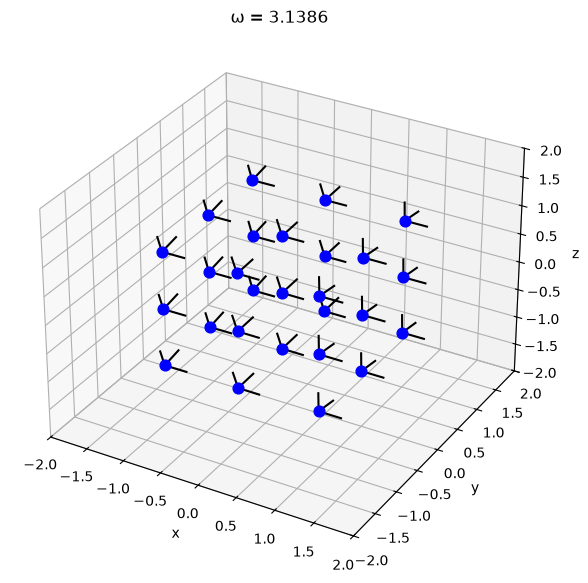

In [6]:
k_index = 35
mode_index = 5

animation = animate_mode(
    crystal,
    kpoints[k_index],
    eigenvectors[k_index, :, mode_index],
    frequencies[k_index, mode_index],
    cells=[
        (i, j, k)
        for i in range(-1, 2)
        for j in range(-1, 2)
        for k in range(-1, 2)
    ],
    amplitude=0.3
);
animation.save('RigidBodyWaves.gif', fps=30);